<a href="https://colab.research.google.com/github/nitinth001/ANN-PROJECT/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#!pip install tensorflow

In [8]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# divide dataset into ind an dep features
x = df.iloc[:,3:13] ## ignoring first 0 ,1 , 2 features + all rows for [:,  ]
y = df.iloc[:,13]
x.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [12]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [13]:
#feature engineering: handling categorical features.. using ohe etc.
geography = pd.get_dummies(x['Geography'], drop_first=True)
gender = pd.get_dummies(x['Gender'], drop_first=True)



In [14]:
#now concatenate these avriables with features give for which we need to firstly drop those categorical already there
x = x.drop(['Geography','Gender'],axis =1) # to drop col only
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [15]:
x = pd.concat([x,geography,gender],axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [16]:
x = x.values
y = y.values

In [17]:
print(x.shape)
print(y.shape)

(10000, 11)
(10000,)


In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

In [19]:
#feature scaling:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)  # learn scaling + apply
x_test = sc.transform(x_test)        # only apply

In [20]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [21]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [22]:
x_train.shape

(8000, 11)

In [23]:
#let's create ANN:
from tensorflow.keras.models import Sequential # to make neural network
from tensorflow.keras.layers import Dense # to make neurons/nodes
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU,ReLU #act func
from tensorflow.keras.layers import Dropout #like regularisation to reduce overfitting

In [24]:
classifier = Sequential()


In [25]:
classifier.add(Dense(units =11, activation='relu')) # adding first input layer
classifier.add(Dense(units =7, activation='relu')) # adding first hidden layer
classifier.add(Dense(units= 6, activation='relu')) # adding second hidden layer


In [26]:
#adding output layer:
classifier.add(Dense(units = 1, activation='sigmoid'))
#

In [27]:
import tensorflow
opt =tensorflow.keras.optimizers.Adam(learning_rate =0.01)

In [28]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])


In [29]:
import tensorflow as tf
from tensorflow import keras
early_stoppings = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [30]:
#train neural network:
model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size= 10, epochs= 1000, callbacks = early_stoppings)


Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7744 - loss: 0.4803 - val_accuracy: 0.8485 - val_loss: 0.3738
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8574 - loss: 0.3498 - val_accuracy: 0.8417 - val_loss: 0.3832
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8508 - loss: 0.3542 - val_accuracy: 0.8561 - val_loss: 0.3602
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8479 - loss: 0.3570 - val_accuracy: 0.8504 - val_loss: 0.3706
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8514 - loss: 0.3491 - val_accuracy: 0.8444 - val_loss: 0.3769
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.3409 - val_accuracy: 0.8538 - val_loss: 0.3613
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8573 - loss: 0.3476 - val_accuracy: 0.8561 - val_loss: 0.3629
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8614 - loss: 0.3458 - 

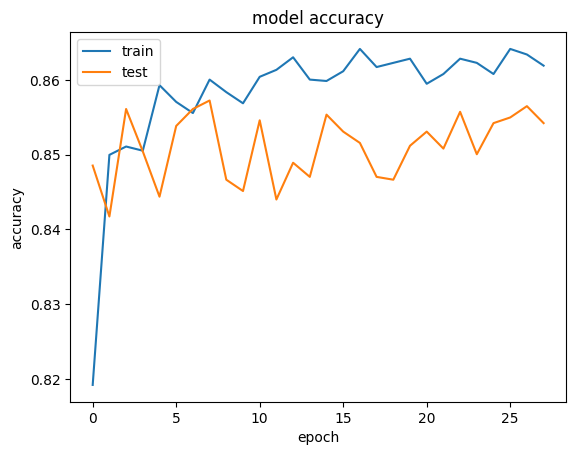

In [31]:
# summarize history for accuracy
import matplotlib.pyplot as plt

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['train', 'test'], loc='upper left')

plt.show()

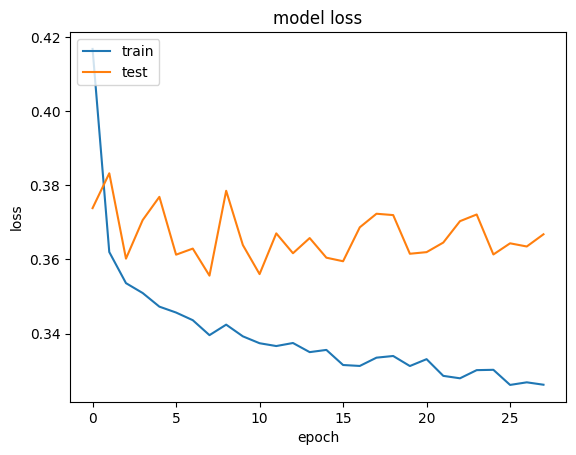

In [32]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['train', 'test'], loc='upper left')

plt.show()

In [33]:
#making predictions and testing results:
from sklearn.metrics import confusion_matrix
y_pred = classifier.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
cm

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[1502,   93],
       [ 187,  218]])

In [34]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.86

In [36]:
classifier.get_weights()

[array([[-1.27626628e-01,  1.69064611e-01, -1.18149817e-03,
          7.51126930e-02,  6.76960349e-01,  3.62364829e-01,
          6.13221467e-01, -2.02135205e-01,  2.04670712e-01,
         -3.93318236e-02,  1.45446748e-01],
        [ 2.97981048e+00,  2.14848220e-01,  2.26495552e+00,
          2.28340554e+00, -1.47502398e+00, -9.36721146e-01,
         -1.28099680e+00, -8.28553975e-01, -6.75224066e-01,
         -5.08296967e-01,  8.93815041e-01],
        [-2.85009086e-01,  3.17606628e-02, -4.09346730e-01,
          3.43060680e-02,  5.30994415e-01,  6.58185303e-01,
         -9.23097551e-01, -7.84908235e-01,  9.71276522e-01,
          9.06902313e-01, -3.88760567e-02],
        [-2.00133756e-01,  7.38576204e-02, -1.09655499e+00,
          3.60785604e-01,  1.37078142e+00, -1.40755785e+00,
          1.03849709e+00, -1.56643204e-02, -3.96703869e-01,
         -3.01334023e+00,  7.73011327e-01],
        [-1.97856677e+00,  3.17749333e+00, -1.63282013e+00,
          2.69307971e+00,  1.36948252e+00, -